# Drug Response Random Forest

This notebook mirrors the structure of `4_Model_implementatin.ipynb` but trains a plain scikit-learn multi-output `RandomForestRegressor` instead of a PyTorch Lightning model. It reuses the same data loading, split assignment, and preprocessor fitting so results can be compared fairly against the Ridge/MLP runs in notebook 4.

The random forest takes **L1000-only** inputs (977 baseline genes + 2048 Morgan fingerprint bits + 1 scaled dose = 3026 features) and predicts the 977-dim delta expression directly (no standardization).


In [1]:
from pathlib import Path

SPLIT_MODE = "drug_blind"  # one of {"drug_blind", "tumor_blind", "mixed"}
SPLIT_FRACTIONS = {"train": 0.8, "val": 0.1, "test": 0.1}
RANDOM_SEED = 42
NUM_WORKERS = 0

MODEL_NAME = "random_forest"
TARGET_MODE = "delta"
PREPROCESS_BATCH_SIZE = 1024

RF_N_ESTIMATORS = 100
RF_MAX_DEPTH = 20
RF_MIN_SAMPLES_LEAF = 5
RF_MAX_FEATURES = "sqrt"
RF_N_JOBS = -1
RF_OOB_SCORE = True
TRAIN_ROW_SUBSAMPLE_FRACTION = None  # set to a float in (0, 1] to subsample training rows for smoke runs

PLOT_TEST_SAMPLE_COUNT = 50
PLOT_TEST_SAMPLE_STRATEGY = "seeded_random"
PLOT_RANDOM_SEED = RANDOM_SEED
EMBEDDING_METHOD = "pca"
N_EMBEDDING_COMPONENTS = 2

TENSOR_ARTIFACTS_DIR = Path("data/Tahoe100M_tensor_artifacts_L1000")
SKLEARN_OUTPUT_DIR = Path("artifacts/sklearn/random_forest")

print(
    {
        "SPLIT_MODE": SPLIT_MODE,
        "SPLIT_FRACTIONS": SPLIT_FRACTIONS,
        "RANDOM_SEED": RANDOM_SEED,
        "NUM_WORKERS": NUM_WORKERS,
        "MODEL_NAME": MODEL_NAME,
        "TARGET_MODE": TARGET_MODE,
        "PREPROCESS_BATCH_SIZE": PREPROCESS_BATCH_SIZE,
        "RF_N_ESTIMATORS": RF_N_ESTIMATORS,
        "RF_MAX_DEPTH": RF_MAX_DEPTH,
        "RF_MIN_SAMPLES_LEAF": RF_MIN_SAMPLES_LEAF,
        "RF_MAX_FEATURES": RF_MAX_FEATURES,
        "RF_N_JOBS": RF_N_JOBS,
        "RF_OOB_SCORE": RF_OOB_SCORE,
        "TRAIN_ROW_SUBSAMPLE_FRACTION": TRAIN_ROW_SUBSAMPLE_FRACTION,
        "PLOT_TEST_SAMPLE_COUNT": PLOT_TEST_SAMPLE_COUNT,
        "PLOT_TEST_SAMPLE_STRATEGY": PLOT_TEST_SAMPLE_STRATEGY,
        "PLOT_RANDOM_SEED": PLOT_RANDOM_SEED,
        "EMBEDDING_METHOD": EMBEDDING_METHOD,
        "N_EMBEDDING_COMPONENTS": N_EMBEDDING_COMPONENTS,
        "tumor_blind_behavior": "cell_line_blind",
        "model_family": "sklearn_random_forest",
    }
)


{'SPLIT_MODE': 'drug_blind', 'SPLIT_FRACTIONS': {'train': 0.8, 'val': 0.1, 'test': 0.1}, 'RANDOM_SEED': 42, 'NUM_WORKERS': 0, 'MODEL_NAME': 'random_forest', 'TARGET_MODE': 'delta', 'PREPROCESS_BATCH_SIZE': 1024, 'RF_N_ESTIMATORS': 100, 'RF_MAX_DEPTH': 20, 'RF_MIN_SAMPLES_LEAF': 5, 'RF_MAX_FEATURES': 'sqrt', 'RF_N_JOBS': -1, 'RF_OOB_SCORE': True, 'TRAIN_ROW_SUBSAMPLE_FRACTION': None, 'PLOT_TEST_SAMPLE_COUNT': 50, 'PLOT_TEST_SAMPLE_STRATEGY': 'seeded_random', 'PLOT_RANDOM_SEED': 42, 'EMBEDDING_METHOD': 'pca', 'N_EMBEDDING_COMPONENTS': 2, 'tumor_blind_behavior': 'cell_line_blind', 'model_family': 'sklearn_random_forest'}


## Imports and Helpers


In [2]:
import json
import sys
import time
from pathlib import Path

import joblib
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor

for candidate_root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate_root / "pyproject.toml").exists() and (candidate_root / "Machine_Learning" / "ml_pipeline").exists():
        candidate_root_str = str(candidate_root)
        if candidate_root_str not in sys.path:
            sys.path.insert(0, candidate_root_str)
        break
else:
    raise ModuleNotFoundError(
        "Could not resolve the project root needed to import Machine_Learning.ml_pipeline."
    )

from Machine_Learning.ml_pipeline.data import TrainingPreprocessor
from Machine_Learning.ml_pipeline.utils import (
    SPLIT_NAMES,
    assign_group_blind_splits,
    assign_mixed_split,
    build_overlap_diagnostics,
    build_project_path,
    build_rf_training_arrays,
    build_sklearn_prediction_pair_embedding,
    build_split_summary,
    compute_condition_retrieval,
    compute_null_baselines_from_arrays,
    evaluate_sklearn_predictions,
    load_cached_cell_line_metadata,
    resolve_project_path,
    resolve_retrieval_label_column,
    resolve_target_gene_indices,
    sample_prediction_details,
    write_performance_metrics,
    validate_plot_config,
    validate_split_assignments,
    validate_split_config,
)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")


## Load Tensors and Supporting Metadata


In [3]:
validate_split_config(SPLIT_MODE, SPLIT_FRACTIONS)
validate_plot_config(
    PLOT_TEST_SAMPLE_COUNT,
    PLOT_TEST_SAMPLE_STRATEGY,
    EMBEDDING_METHOD,
    N_EMBEDDING_COMPONENTS,
)
if MODEL_NAME != "random_forest":
    raise ValueError(f"This notebook only supports MODEL_NAME='random_forest'; got {MODEL_NAME}")
if TARGET_MODE != "delta":
    raise ValueError(f"This notebook only supports TARGET_MODE='delta'; got {TARGET_MODE}")
if TRAIN_ROW_SUBSAMPLE_FRACTION is not None and not (0.0 < float(TRAIN_ROW_SUBSAMPLE_FRACTION) <= 1.0):
    raise ValueError("TRAIN_ROW_SUBSAMPLE_FRACTION must be None or a float in (0, 1].")

tensor_artifacts_dir = resolve_project_path(TENSOR_ARTIFACTS_DIR)
dmso_bundle = torch.load(tensor_artifacts_dir / "dmso_baselines.pt", map_location="cpu")
treatment_bundle = torch.load(tensor_artifacts_dir / "treatment_expressions.pt", map_location="cpu")
fingerprint_bundle = torch.load(tensor_artifacts_dir / "morgan_fingerprints.pt", map_location="cpu")

input_gene_ids = [str(gene_id) for gene_id in dmso_bundle["gene_ids"]]
target_gene_ids = [str(gene_id) for gene_id in treatment_bundle["gene_ids"]]
target_gene_indices = resolve_target_gene_indices(input_gene_ids, target_gene_ids)

treatment_feature_space = str(treatment_bundle.get("feature_space", "unknown"))
available_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("available_landmark_gene_ids", target_gene_ids)
]
if available_landmark_gene_ids and target_gene_ids != available_landmark_gene_ids:
    raise ValueError("Treatment target gene_ids do not match available_landmark_gene_ids metadata.")
if len(target_gene_indices) != len(target_gene_ids):
    raise ValueError("Resolved target gene indices do not match the saved treatment target width.")

cell_line_metadata_df, cell_line_metadata_arrow_path = load_cached_cell_line_metadata()
tensor_cell_lines = set(dmso_bundle["cell_lines"])
matched_cell_line_metadata_df = cell_line_metadata_df.loc[
    cell_line_metadata_df["cell_line"].isin(tensor_cell_lines)
].copy()
missing_cell_line_metadata = sorted(tensor_cell_lines - set(matched_cell_line_metadata_df["cell_line"]))
if missing_cell_line_metadata:
    raise ValueError(f"Missing cell-line metadata for: {missing_cell_line_metadata}")
if matched_cell_line_metadata_df["cell_line"].duplicated().any():
    raise ValueError("cell_line metadata must be unique after deduplication.")

examples_df = pd.DataFrame(
    {
        "condition_key": treatment_bundle["condition_keys"],
        "cell_line": treatment_bundle["cell_lines"],
        "file_name": treatment_bundle["file_names"],
        "drug": treatment_bundle["drug_names"],
        "concentration": treatment_bundle["concentrations"].cpu().numpy().astype(np.float32),
        "concentration_unit": treatment_bundle["concentration_units"],
        "target_index": np.arange(len(treatment_bundle["condition_keys"]), dtype=np.int64),
    }
)
examples_df["baseline_index"] = examples_df["cell_line"].map(dmso_bundle["cell_line_to_index"])
examples_df["fingerprint_index"] = examples_df["drug"].map(fingerprint_bundle["drug_to_index"])

if examples_df["condition_key"].duplicated().any():
    raise ValueError("condition_key values must be unique in the treatment bundle.")
if examples_df["baseline_index"].isna().any():
    raise ValueError("Some treatment rows do not resolve to a DMSO baseline index.")
if examples_df["fingerprint_index"].isna().any():
    raise ValueError("Some treatment rows do not resolve to a Morgan fingerprint index.")

examples_df = examples_df.merge(
    matched_cell_line_metadata_df,
    on="cell_line",
    how="left",
    validate="many_to_one",
)
if examples_df[["cell_name", "organ"]].isna().any().any():
    raise ValueError("Some treatment rows do not resolve to cell-line metadata.")

examples_df[["baseline_index", "fingerprint_index", "target_index"]] = examples_df[[
    "baseline_index",
    "fingerprint_index",
    "target_index",
]].astype(int)

tensor_summary_df = pd.DataFrame(
    [
        {
            "bundle": "dmso_baselines",
            "rows": int(dmso_bundle["expressions"].shape[0]),
            "cols": int(dmso_bundle["expressions"].shape[1]),
            "feature_space": "full_protein_coding",
        },
        {
            "bundle": "treatment_expressions",
            "rows": int(treatment_bundle["expressions"].shape[0]),
            "cols": int(treatment_bundle["expressions"].shape[1]),
            "feature_space": treatment_feature_space,
        },
        {
            "bundle": "morgan_fingerprints",
            "rows": int(fingerprint_bundle["fingerprints"].shape[0]),
            "cols": int(fingerprint_bundle["fingerprints"].shape[1]),
            "feature_space": "morgan_radius2_bits2048",
        },
    ]
)
metadata_summary_df = pd.DataFrame(
    [
        {
            "tensor_artifacts_dir": str(tensor_artifacts_dir),
            "cell_line_metadata_arrow_path": str(cell_line_metadata_arrow_path),
            "n_examples": int(len(examples_df)),
            "n_unique_drugs": int(examples_df["drug"].nunique()),
            "n_unique_cell_lines": int(examples_df["cell_line"].nunique()),
            "n_unique_organs": int(examples_df["organ"].nunique()),
        }
    ]
)
print(
    f"Loaded {len(examples_df)} treatment examples with {len(input_gene_ids)} input genes and {len(target_gene_ids)} target genes in feature space {treatment_feature_space}."
)
display(tensor_summary_df)
display(metadata_summary_df)
display(examples_df.head())


Loaded 26696 treatment examples with 20061 input genes and 977 target genes in feature space l1000_landmark_intersection.


,bundle,rows,cols,feature_space
0,dmso_baselines,24,20061,full_protein_coding
1,treatment_expressions,26696,977,l1000_landmark_intersection
2,morgan_fingerprints,377,2048,morgan_radius2_bits2048


,tensor_artifacts_dir,cell_line_metadata_arrow_path,n_examples,n_unique_drugs,n_unique_cell_lines,n_unique_organs
0,/Users/liamwilson/dl_fin/deep-learning-final-p...,/Users/liamwilson/.cache/huggingface/datasets/...,26696,377,24,10


,condition_key,cell_line,file_name,drug,concentration,concentration_unit,target_index,baseline_index,fingerprint_index,cell_name,organ
0,CVCL_0023|||(R)-Verapamil (hydrochloride)|||0....,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),0.05,uM,0,0,118,A549,Lung
1,CVCL_0023|||(R)-Verapamil (hydrochloride)|||0....,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),0.50,uM,1,0,118,A549,Lung
2,CVCL_0023|||(R)-Verapamil (hydrochloride)|||5|...,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),5.00,uM,2,0,118,A549,Lung
3,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,CVCL_0023.h5ad,(S)-Crizotinib,0.05,uM,3,0,137,A549,Lung
4,CVCL_0023|||(S)-Crizotinib|||0.5|||uM,CVCL_0023,CVCL_0023.h5ad,(S)-Crizotinib,0.50,uM,4,0,137,A549,Lung


## Split Examples

Same split logic as notebook 4, but no DataLoader construction since the Random Forest is fit on flat numpy arrays.


In [4]:
if SPLIT_MODE == "drug_blind":
    split_mode_note = "drug_blind: entire drugs are held out from train."
    split_unit_column = "drug"
    split_assignments = assign_group_blind_splits(
        examples_df,
        group_col="drug",
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )
elif SPLIT_MODE == "tumor_blind":
    split_mode_note = "tumor_blind: this notebook implements cell-line-blind splits rather than Organ-level splits."
    split_unit_column = "cell_line"
    split_assignments = assign_group_blind_splits(
        examples_df,
        group_col="cell_line",
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )
else:
    split_mode_note = "mixed: condition keys are held out, but every drug and cell line remains represented in train."
    split_unit_column = "condition_key"
    split_assignments = assign_mixed_split(
        examples_df,
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )

split_examples_df = examples_df.copy()
split_examples_df["split"] = split_assignments.to_numpy()
validate_split_assignments(split_examples_df, SPLIT_MODE)

split_summary_df = build_split_summary(split_examples_df, SPLIT_FRACTIONS)
split_unit_summary_df = (
    split_examples_df.groupby("split")[split_unit_column]
    .nunique()
    .reindex(SPLIT_NAMES)
    .reset_index(name=f"unique_{split_unit_column}_count")
)
overlap_diagnostics_df = build_overlap_diagnostics(split_examples_df, SPLIT_MODE)

train_examples_df = split_examples_df.loc[split_examples_df["split"] == "train"].reset_index(drop=True)
val_examples_df = split_examples_df.loc[split_examples_df["split"] == "val"].reset_index(drop=True)
test_examples_df = split_examples_df.loc[split_examples_df["split"] == "test"].reset_index(drop=True)
split_sample_counts = {split_name: int((split_examples_df["split"] == split_name).sum()) for split_name in SPLIT_NAMES}

print(
    f"Using {SPLIT_MODE} split. {split_mode_note} Sample counts -> train: {split_sample_counts['train']}, val: {split_sample_counts['val']}, test: {split_sample_counts['test']}."
)
display(split_summary_df)
display(split_unit_summary_df)
display(overlap_diagnostics_df)


Using drug_blind split. drug_blind: entire drugs are held out from train. Sample counts -> train: 21368, val: 2664, test: 2664.


,split,target_rows,row_count,requested_fraction,realized_fraction,unique_drugs,unique_cell_lines,unique_organs
0,train,21356,21368,0.8,0.80042,303,24,10
1,val,2670,2664,0.1,0.09979,37,24,10
2,test,2670,2664,0.1,0.09979,37,24,10


,split,unique_drug_count
0,train,303
1,val,37
2,test,37


,entity,pair,overlap_count
0,drug,train/val,0
1,drug,train/test,0
2,drug,val/test,0
3,condition_key,train/val,0
4,condition_key,train/test,0
5,condition_key,val/test,0
6,cell_line,train/val,24
7,cell_line,train/test,24
8,cell_line,val/test,24


## Fit the Training Preprocessor

The `TrainingPreprocessor` computes three groups of statistics:

1. **`baseline_mean` / `baseline_std` / `normalized_dmso_input_expression_lookup`** over the full ~20k input gene space. Random forests are scale-invariant, so these are **not used** by the RF path. They are still computed to keep preprocessor output identical to notebook 4's Ridge/MLP runs so cross-model comparisons stay apples-to-apples.
2. **`dose_log_mean` / `dose_log_std`** for scaling the log10 concentration. The RF **does** use these via `build_rf_training_arrays`.
3. **`delta_mean` / `delta_std`** of the 977-dim target delta. The RF trains directly on raw delta (no standardization), so these are also unused here; they are kept for parity.

The fit is intentionally wasteful; the alternative (skipping it) would make RF results less directly comparable to notebook 4.


In [5]:
training_preprocessor = TrainingPreprocessor(
    train_examples_df=train_examples_df,
    dmso_bundle=dmso_bundle,
    treatment_bundle=treatment_bundle,
    fingerprint_bundle=fingerprint_bundle,
    target_gene_indices=target_gene_indices,
    target_mode=TARGET_MODE,
    batch_size=PREPROCESS_BATCH_SIZE,
).fit()

preprocessor_summary_df = training_preprocessor.summary_frame()
display(preprocessor_summary_df)


,target_mode,train_examples,input_dim,input_gene_dim,target_gene_dim,fingerprint_dim,dose_log_mean,dose_log_std,baseline_std_min,delta_std_min
0,delta,21368,22110,20061,977,2048,-0.307488,0.816949,0.001,0.198753


## Assemble Random Forest Training Arrays

Build the flat `(X, y, baseline)` numpy arrays for each split using the preprocessor's cached lookup tensors. Optionally subsample training rows for smoke runs via `TRAIN_ROW_SUBSAMPLE_FRACTION`.


In [6]:
X_train_full, y_train_full, baseline_train_full = build_rf_training_arrays(training_preprocessor, train_examples_df)
X_val, y_val, baseline_val = build_rf_training_arrays(training_preprocessor, val_examples_df)
X_test, y_test, baseline_test = build_rf_training_arrays(training_preprocessor, test_examples_df)

expected_input_dim = int(training_preprocessor.target_gene_dim + training_preprocessor.fingerprint_dim + 1)
expected_target_dim = int(training_preprocessor.target_gene_dim)

for split_name, X_split, y_split, baseline_split in (
    ("train", X_train_full, y_train_full, baseline_train_full),
    ("val", X_val, y_val, baseline_val),
    ("test", X_test, y_test, baseline_test),
):
    if X_split.shape[1] != expected_input_dim:
        raise ValueError(
            f"{split_name} X width {X_split.shape[1]} does not match expected input dim {expected_input_dim}."
        )
    if y_split.shape[1] != expected_target_dim:
        raise ValueError(
            f"{split_name} y width {y_split.shape[1]} does not match expected target gene dim {expected_target_dim}."
        )
    if baseline_split.shape != y_split.shape:
        raise ValueError(
            f"{split_name} baseline shape {baseline_split.shape} does not match y shape {y_split.shape}."
        )
    if np.any(baseline_split < 0):
        raise ValueError(f"{split_name} baseline contains negative values; expected log-normalized expression >= 0.")

if TRAIN_ROW_SUBSAMPLE_FRACTION is not None and TRAIN_ROW_SUBSAMPLE_FRACTION < 1.0:
    rng = np.random.default_rng(RANDOM_SEED)
    n_subsample = max(1, int(round(len(X_train_full) * float(TRAIN_ROW_SUBSAMPLE_FRACTION))))
    subsample_indices = rng.choice(len(X_train_full), size=n_subsample, replace=False)
    subsample_indices.sort()
    X_train = X_train_full[subsample_indices]
    y_train = y_train_full[subsample_indices]
    baseline_train = baseline_train_full[subsample_indices]
    train_examples_df_used = train_examples_df.iloc[subsample_indices].reset_index(drop=True)
else:
    X_train = X_train_full
    y_train = y_train_full
    baseline_train = baseline_train_full
    train_examples_df_used = train_examples_df

model_summary_df = pd.DataFrame(
    [
        {
            "model_family": "random_forest",
            "input_feature_dim": int(X_train.shape[1]),
            "target_gene_dim": int(y_train.shape[1]),
            "n_train_rows": int(X_train.shape[0]),
            "n_val_rows": int(X_val.shape[0]),
            "n_test_rows": int(X_test.shape[0]),
            "train_row_subsample_fraction": TRAIN_ROW_SUBSAMPLE_FRACTION,
            "rf_n_estimators": RF_N_ESTIMATORS,
            "rf_max_depth": RF_MAX_DEPTH,
            "rf_min_samples_leaf": RF_MIN_SAMPLES_LEAF,
            "rf_max_features": RF_MAX_FEATURES,
            "rf_n_jobs": RF_N_JOBS,
            "rf_oob_score": RF_OOB_SCORE,
            "treatment_feature_space": treatment_feature_space,
        }
    ]
)
print(
    f"Built RF arrays -> X_train {X_train.shape}, y_train {y_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}."
)
display(model_summary_df)


Built RF arrays -> X_train (21368, 3026), y_train (21368, 977), X_val (2664, 3026), X_test (2664, 3026).


,model_family,input_feature_dim,target_gene_dim,n_train_rows,n_val_rows,n_test_rows,train_row_subsample_fraction,rf_n_estimators,rf_max_depth,rf_min_samples_leaf,rf_max_features,rf_n_jobs,rf_oob_score,treatment_feature_space
0,random_forest,3026,977,21368,2664,2664,None,100,20,5,sqrt,-1,True,l1000_landmark_intersection


## Train the Random Forest

A single call to `RandomForestRegressor.fit` does a multi-output regression over all 977 target genes simultaneously. Fit time scales roughly with `n_estimators * n_train_rows * log(n_train_rows) * sqrt(n_features) * n_outputs`; use `TRAIN_ROW_SUBSAMPLE_FRACTION` to throttle if needed.


In [7]:
L.seed_everything(RANDOM_SEED, workers=True)

rf_kwargs = {
    "n_estimators": int(RF_N_ESTIMATORS),
    "max_depth": None if RF_MAX_DEPTH is None else int(RF_MAX_DEPTH),
    "min_samples_leaf": int(RF_MIN_SAMPLES_LEAF),
    "max_features": RF_MAX_FEATURES,
    "n_jobs": int(RF_N_JOBS),
    "oob_score": bool(RF_OOB_SCORE),
    "random_state": int(RANDOM_SEED),
}
rf_estimator = RandomForestRegressor(**rf_kwargs)

fit_start = time.perf_counter()
rf_estimator.fit(X_train, y_train)
fit_seconds = float(time.perf_counter() - fit_start)

run_name = f"{SPLIT_MODE}_{MODEL_NAME}_{TARGET_MODE}"
sklearn_output_dir = build_project_path(SKLEARN_OUTPUT_DIR)
run_output_dir = sklearn_output_dir / run_name
run_output_dir.mkdir(parents=True, exist_ok=True)

estimator_path = run_output_dir / "random_forest.joblib"
joblib.dump(rf_estimator, estimator_path)

oob_score = float(rf_estimator.oob_score_) if RF_OOB_SCORE else None
training_run_summary = {
    "run_name": run_name,
    "estimator_path": str(estimator_path),
    "fit_seconds": fit_seconds,
    "oob_score": oob_score,
    "n_train_rows": int(X_train.shape[0]),
    "n_val_rows": int(X_val.shape[0]),
    "n_test_rows": int(X_test.shape[0]),
    "rf_kwargs": rf_kwargs,
    "train_row_subsample_fraction": TRAIN_ROW_SUBSAMPLE_FRACTION,
    "split_mode": SPLIT_MODE,
    "target_mode": TARGET_MODE,
}
summary_path = run_output_dir / "training_run_summary.json"
summary_path.write_text(json.dumps(training_run_summary, indent=2, default=str))

training_run_summary_df = pd.DataFrame([training_run_summary])
display(training_run_summary_df)


Seed set to 42


,run_name,estimator_path,fit_seconds,oob_score,n_train_rows,n_val_rows,n_test_rows,rf_kwargs,train_row_subsample_fraction,split_mode,target_mode
0,drug_blind_random_forest_delta,/Users/liamwilson/dl_fin/deep-learning-final-p...,37.438821,0.119832,21368,2664,2664,"{'n_estimators': 100, 'max_depth': 20, 'min_sa...",None,drug_blind,delta


## Evaluate the Fitted Random Forest

Uses `evaluate_sklearn_predictions`, which produces the same `(metrics, inspection_df, prediction_details_df)` schema as `evaluate_model_on_loader` in notebook 4.


In [8]:
predicted_delta_by_split = {
    "train": rf_estimator.predict(X_train),
    "val": rf_estimator.predict(X_val),
    "test": rf_estimator.predict(X_test),
}
split_arrays = {
    "train": (X_train, y_train, baseline_train, train_examples_df_used),
    "val": (X_val, y_val, baseline_val, val_examples_df),
    "test": (X_test, y_test, baseline_test, test_examples_df),
}

evaluation_rows = []
inspection_tables = {}
prediction_detail_tables = {}
for split_name, (_, y_split, baseline_split, metadata_split) in split_arrays.items():
    metrics_row, inspection_df, prediction_details_df = evaluate_sklearn_predictions(
        predicted_delta_np=predicted_delta_by_split[split_name],
        target_delta_np=y_split,
        baseline_np=baseline_split,
        metadata_df=metadata_split,
        split_name=split_name,
        gene_ids=target_gene_ids,
    )
    evaluation_rows.append(metrics_row)
    inspection_tables[split_name] = inspection_df
    prediction_detail_tables[split_name] = prediction_details_df

evaluation_summary_df = pd.DataFrame(evaluation_rows)
evaluation_summary_df.insert(0, "predictor", "model")

null_baseline_rows = compute_null_baselines_from_arrays(
    {
        "train": (baseline_train, y_train, train_examples_df_used),
        "val": (baseline_val, y_val, val_examples_df),
        "test": (baseline_test, y_test, test_examples_df),
    },
    gene_ids=target_gene_ids,
)
null_baselines_df = pd.DataFrame(null_baseline_rows)
evaluation_summary_df = pd.concat(
    [null_baselines_df, evaluation_summary_df],
    ignore_index=True,
)

retrieval_label_column = resolve_retrieval_label_column(SPLIT_MODE)
retrieval_rows = []
for split_name, (_, y_split, _, metadata_split) in split_arrays.items():
    retrieval_labels = metadata_split[retrieval_label_column].astype(str).to_numpy()
    retrieval_rows.append(
        {
            "split": split_name,
            "label_column": retrieval_label_column,
            **compute_condition_retrieval(
                predicted_delta_by_split[split_name],
                y_split,
                retrieval_labels,
            ),
        }
    )
retrieval_summary_df = pd.DataFrame(retrieval_rows)

test_prediction_details_df = prediction_detail_tables["test"].copy()
print(f"Evaluated fitted random forest from {estimator_path}")
display(evaluation_summary_df)
display(retrieval_summary_df)
display(inspection_tables["test"])
display(test_prediction_details_df.head())


Evaluated fitted random forest from /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/sklearn/random_forest/drug_blind_random_forest_delta/random_forest.joblib


,split,n_samples,delta_mse,delta_mae,treated_cosine,mann_whitney_u_median,mann_whitney_pvalue_mean,mann_whitney_pvalue_median,mann_whitney_not_significant_fraction,top50_deg_match_count_mean,...,delta_cosine_mean,delta_pearson_mean,delta_pearson_median,delta_spearman_mean,delta_spearman_median,delta_r2_vs_zero_mean,delta_r2_vs_zero_median,magnitude_ratio_mean,predictor,cell_line_mean_fell_back
0,train,21368,802.178046,9.289790,0.972141,487407.5,0.199551,0.038351,0.475711,1.788562,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,zero,NaN
1,train,21368,762.666034,9.179876,0.972944,479802.0,0.209661,0.050914,0.502153,18.355344,...,0.280618,0.286893,0.332505,0.235636,0.252598,0.048607,0.082896,0.342442,global_mean,NaN
2,train,21368,699.501272,8.646281,0.976723,487027.5,0.203281,0.040975,0.483995,24.586438,...,0.408743,0.419708,0.502781,0.316806,0.330563,0.153406,0.200391,0.439952,cell_line_mean,False
3,val,2664,633.248447,8.753595,0.978583,477622.5,0.226869,0.075690,0.545045,1.715465,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,zero,NaN
4,val,2664,608.932248,8.744977,0.979743,470136.0,0.224305,0.070319,0.537913,17.888889,...,0.269923,0.284061,0.318202,0.222805,0.235918,0.049908,0.076049,0.355225,global_mean,NaN
5,val,2664,578.620487,8.222536,0.982874,476612.0,0.235087,0.081393,0.555556,23.904655,...,0.379045,0.391400,0.475738,0.311479,0.325762,0.132233,0.183641,0.459583,cell_line_mean,False
6,test,2664,643.457201,8.386231,0.981084,479521.0,0.237922,0.082491,0.550676,1.715090,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,zero,NaN
7,test,2664,615.807353,8.364726,0.982694,472059.0,0.246016,0.089449,0.558183,18.415916,...,0.294013,0.308106,0.361967,0.229974,0.260359,0.069917,0.098087,0.363108,global_mean,NaN
8,test,2664,592.977616,7.846832,0.985644,479289.5,0.238852,0.083661,0.560060,24.641141,...,0.399764,0.411573,0.524080,0.319630,0.346070,0.166891,0.230634,0.463949,cell_line_mean,False
9,train,21368,561.181495,7.955038,0.980959,486583.5,0.216795,0.059462,0.515818,26.918383,...,0.538181,0.544324,0.616513,0.445505,0.458175,0.268529,0.300457,0.461358,model,NaN


,split,label_column,n_samples,n_labels,mean_rank,median_rank,top1,chance_top1,top5,chance_top5
0,train,drug,21368,303,105.497566,85.0,0.035193,0.003300,0.092007,0.016502
1,val,drug,2664,37,18.653529,19.0,0.031907,0.027027,0.152778,0.135135
2,test,drug,2664,37,18.995120,19.0,0.028904,0.027027,0.141141,0.135135


,split,condition_key,cell_line,drug,concentration,sample_delta_mse,sample_treated_cosine,sample_mann_whitney_u,sample_mann_whitney_pvalue,sample_top50_deg_match_count,...,pred_ENSG00000000003,target_ENSG00000000003,pred_ENSG00000000457,target_ENSG00000000457,pred_ENSG00000002330,target_ENSG00000002330,pred_ENSG00000002549,target_ENSG00000002549,pred_ENSG00000002919,target_ENSG00000002919
0,test,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,(S)-Crizotinib,0.05,225.345123,0.979119,506753.0,0.018047,33.0,...,3.382119,4.257095,4.004435,2.587646,3.549739,3.923205,29.597591,23.706177,4.629330,3.255426
1,test,CVCL_0023|||(S)-Crizotinib|||0.5|||uM,CVCL_0023,(S)-Crizotinib,0.50,77.852043,0.992493,502194.0,0.045601,28.0,...,3.383244,2.905129,4.015709,3.449841,3.545822,3.540627,29.600861,28.960508,4.635844,5.356332
2,test,CVCL_0023|||(S)-Crizotinib|||5|||uM,CVCL_0023,(S)-Crizotinib,5.00,101.490807,0.989193,486347.0,0.466435,30.0,...,3.365866,3.122290,4.039842,3.295750,3.502780,3.989592,29.617126,26.366001,4.633299,4.336514


,split,dataset_index,condition_key,cell_line,cell_name,organ,drug,concentration,concentration_unit,delta_mse,...,mann_whitney_u,mann_whitney_pvalue,top50_deg_match_count,top50_deg_match_fraction,signed_ndcg_at_50,delta_cosine,delta_pearson,delta_spearman,delta_r2_vs_zero,magnitude_ratio
0,test,0,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,A549,Lung,(S)-Crizotinib,0.05,uM,225.345123,...,506753.0,0.018047,33.0,0.66,0.872720,0.817700,0.840806,0.557756,0.486943,0.391448
1,test,1,CVCL_0023|||(S)-Crizotinib|||0.5|||uM,CVCL_0023,A549,Lung,(S)-Crizotinib,0.50,uM,77.852043,...,502194.0,0.045601,28.0,0.56,0.779736,0.705832,0.724018,0.457268,0.496244,0.661621
2,test,2,CVCL_0023|||(S)-Crizotinib|||5|||uM,CVCL_0023,A549,Lung,(S)-Crizotinib,5.00,uM,101.490807,...,486347.0,0.466435,30.0,0.60,0.802648,0.737351,0.737656,0.449833,0.514683,0.567045
3,test,3,CVCL_0023|||Abiraterone acetate|||0.05|||uM,CVCL_0023,A549,Lung,Abiraterone acetate,0.05,uM,195.728180,...,498905.0,0.082684,30.0,0.60,0.768632,0.663435,0.676682,0.438635,0.398656,0.459744
4,test,4,CVCL_0023|||Abiraterone acetate|||0.5|||uM,CVCL_0023,A549,Lung,Abiraterone acetate,0.50,uM,224.852005,...,471197.0,0.626602,29.0,0.58,0.628034,0.541699,0.545489,0.573056,0.287827,0.466794


## Training Summary and Train/Val Diagnostic Tables

Random Forest has no per-epoch loss, so the train/val line plot from notebook 4 is replaced by a training-run summary plus the same Mann-Whitney and DEG diagnostic tables, and a bar plot of mean Mann-Whitney p-value.


,run_name,estimator_path,fit_seconds,oob_score,n_train_rows,n_val_rows,n_test_rows,rf_kwargs,train_row_subsample_fraction,split_mode,target_mode
0,drug_blind_random_forest_delta,/Users/liamwilson/dl_fin/deep-learning-final-p...,37.438821,0.119832,21368,2664,2664,"{'n_estimators': 100, 'max_depth': 20, 'min_sa...",None,drug_blind,delta


,split,mann_whitney_pvalue_mean,mann_whitney_pvalue_median,mann_whitney_not_significant_fraction
0,train,0.199551,0.038351,0.475711
1,train,0.209661,0.050914,0.502153
2,train,0.203281,0.040975,0.483995
3,train,0.216795,0.059462,0.515818
4,val,0.226869,0.075690,0.545045
5,val,0.224305,0.070319,0.537913
6,val,0.235087,0.081393,0.555556
7,val,0.231754,0.081015,0.551051


,split,top50_deg_match_count_mean,top50_deg_match_count_median,top50_deg_match_fraction_mean,top50_deg_match_fraction_median,signed_ndcg_at_50_mean,signed_ndcg_at_50_median
0,train,1.788562,2.0,0.035771,0.04,0.000000,0.000000
1,train,18.355344,18.0,0.367107,0.36,0.422683,0.426442
2,train,24.586438,24.0,0.491729,0.48,0.570241,0.601586
3,train,26.918383,27.0,0.538368,0.54,0.650788,0.680112
4,val,1.715465,2.0,0.034309,0.04,0.000000,0.000000
5,val,17.888889,18.0,0.357778,0.36,0.408425,0.404876
6,val,23.904655,24.0,0.478093,0.48,0.546830,0.575362
7,val,24.159159,24.0,0.483183,0.48,0.551830,0.586416


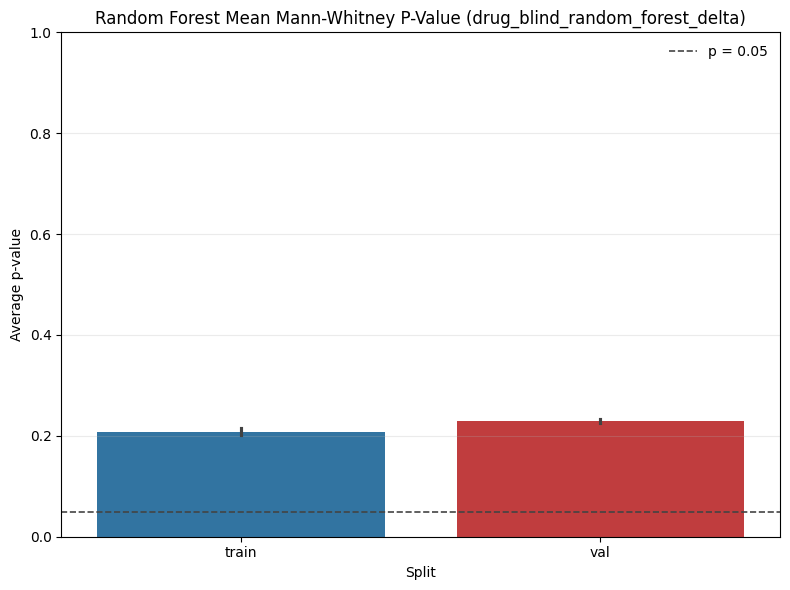

In [9]:
train_val_mann_whitney_summary_df = (
    evaluation_summary_df.loc[evaluation_summary_df["split"].isin(["train", "val"])]
    .copy()
    .sort_values("split", key=lambda s: s.map({"train": 0, "val": 1}), ignore_index=True)
)

display(training_run_summary_df)
display(
    train_val_mann_whitney_summary_df[
        [
            "split",
            "mann_whitney_pvalue_mean",
            "mann_whitney_pvalue_median",
            "mann_whitney_not_significant_fraction",
        ]
    ]
)
display(
    train_val_mann_whitney_summary_df[
        [
            "split",
            "top50_deg_match_count_mean",
            "top50_deg_match_count_median",
            "top50_deg_match_fraction_mean",
            "top50_deg_match_fraction_median",
            "signed_ndcg_at_50_mean",
            "signed_ndcg_at_50_median",
        ]
    ]
)

fig, pvalue_ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=train_val_mann_whitney_summary_df,
    x="split",
    y="mann_whitney_pvalue_mean",
    hue="split",
    order=["train", "val"],
    hue_order=["train", "val"],
    palette={"train": "#1f77b4", "val": "#d62728"},
    dodge=False,
    legend=False,
    ax=pvalue_ax,
)
pvalue_ax.axhline(0.05, color="#444444", linestyle="--", linewidth=1.2, label="p = 0.05")
pvalue_ax.set_title(f"Random Forest Mean Mann-Whitney P-Value ({run_name})")
pvalue_ax.set_xlabel("Split")
pvalue_ax.set_ylabel("Average p-value")
pvalue_ax.set_ylim(0, max(1.0, float(train_val_mann_whitney_summary_df["mann_whitney_pvalue_mean"].max()) * 1.1))
pvalue_ax.grid(True, axis="y", alpha=0.25)
pvalue_ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()


## Plot Predicted vs Actual Test Pairs


Plotted 50 seeded_random test pairs with PCA using the fitted random forest.


,pair_index,condition_key,cell_line,drug,concentration,concentration_unit,treated_mse,delta_mse,treated_cosine,mann_whitney_u,mann_whitney_pvalue,top50_deg_match_count,top50_deg_match_fraction,signed_ndcg_at_50,delta_cosine,delta_pearson,delta_spearman,delta_r2_vs_zero,magnitude_ratio,pair_distance_2d
0,15,CVCL_0131|||Olanzapine|||5|||uM,CVCL_0131,Olanzapine,5.00,uM,3510.598877,3510.598877,0.967663,396579.0,9.789363e-11,21.0,0.42,0.094663,-0.589415,-0.593988,-0.069320,-0.542624,0.354001,1606.171645
1,42,CVCL_0480|||Relugolix|||5|||uM,CVCL_0480,Relugolix,5.00,uM,5762.946289,5762.946289,0.985840,379610.0,4.843138e-15,24.0,0.48,0.215226,-0.202314,-0.241554,-0.027085,-0.132343,0.213948,1405.518135
2,26,CVCL_0332|||Omeprazole (sodium)|||5|||uM,CVCL_0332,Omeprazole (sodium),5.00,uM,1622.792480,1622.792236,0.997981,445979.0,1.211558e-02,21.0,0.42,0.308344,-0.185377,-0.230786,0.452088,-0.292576,0.386410,1162.427139
3,14,CVCL_0131|||Bergenin|||5|||uM,CVCL_0131,Bergenin,5.00,uM,1638.299438,1638.299438,0.976349,438379.0,1.819550e-03,25.0,0.50,0.048846,-0.670331,-0.652007,-0.239412,-1.984654,0.889797,1071.874304
4,32,CVCL_0371|||Everolimus|||5|||uM,CVCL_0371,Everolimus,5.00,uM,1656.573486,1656.573486,0.993662,529852.0,2.475991e-05,22.0,0.44,0.266921,-0.486209,-0.509154,0.177455,-0.675628,0.468792,1035.407328
5,41,CVCL_0480|||Darinaparsin|||5|||uM,CVCL_0480,Darinaparsin,5.00,uM,2276.309082,2276.309082,0.980106,394420.0,3.067335e-11,29.0,0.58,0.603102,0.459861,0.428149,0.523147,0.132456,0.178764,624.853042
6,34,CVCL_0371|||Sapanisertib|||5|||uM,CVCL_0371,Sapanisertib,5.00,uM,748.883301,748.883301,0.983065,501269.0,5.424282e-02,26.0,0.52,0.492200,0.162255,0.149290,0.460645,-0.025698,0.390345,586.316812
7,22,CVCL_0293|||Riluzole hydrochloride|||5|||uM,CVCL_0293,Riluzole hydrochloride,5.00,uM,1547.039185,1547.039185,0.984444,398146.0,2.231351e-10,20.0,0.40,0.179401,-0.140094,-0.005977,-0.270043,-0.324116,0.446202,534.111819
8,31,CVCL_0366|||Omeprazole (sodium)|||5|||uM,CVCL_0366,Omeprazole (sodium),5.00,uM,871.456970,871.456970,0.993922,448298.0,2.018994e-02,21.0,0.42,0.348202,0.023654,0.062558,0.237135,-0.167390,0.433471,504.155577
9,38,CVCL_0428|||Bergenin|||5|||uM,CVCL_0428,Bergenin,5.00,uM,1220.480469,1220.480469,0.980321,463778.0,2.794971e-01,20.0,0.40,0.175950,-0.592134,-0.604062,0.141931,-0.398291,0.273264,496.345723


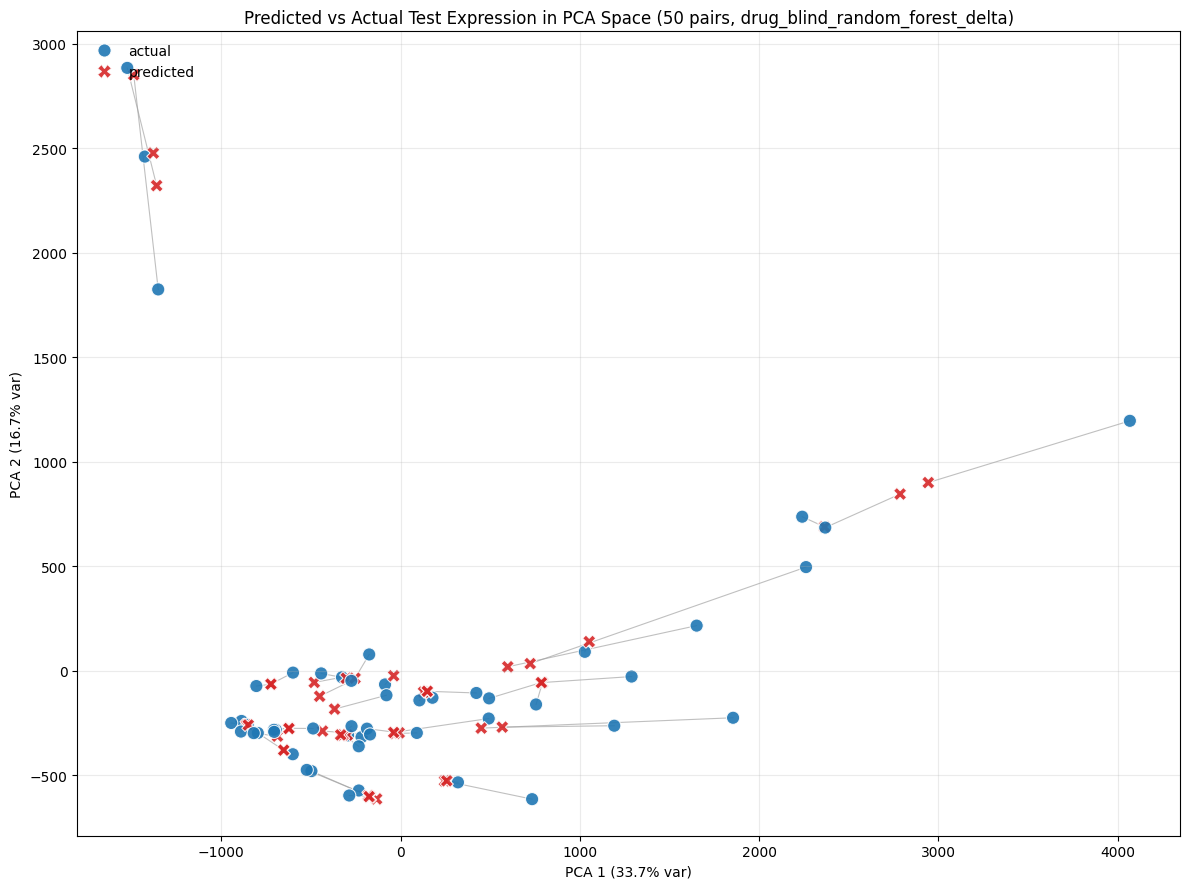

In [10]:
sampled_test_prediction_details_df = sample_prediction_details(
    prediction_details_df=test_prediction_details_df,
    sample_count=PLOT_TEST_SAMPLE_COUNT,
    sample_strategy=PLOT_TEST_SAMPLE_STRATEGY,
    random_seed=PLOT_RANDOM_SEED,
)
test_prediction_plot_df, sampled_test_pair_summary_df, test_embedding_explained_variance_ratio = (
    build_sklearn_prediction_pair_embedding(
        sampled_prediction_details_df=sampled_test_prediction_details_df,
        baseline_np=baseline_test,
        predicted_delta_np=predicted_delta_by_split["test"],
        target_delta_np=y_test,
        embedding_method=EMBEDDING_METHOD,
        n_components=N_EMBEDDING_COMPONENTS,
    )
)

print(
    f"Plotted {len(sampled_test_prediction_details_df)} {PLOT_TEST_SAMPLE_STRATEGY} test pairs with {EMBEDDING_METHOD.upper()} using the fitted random forest."
)
display(sampled_test_pair_summary_df)

fig, ax = plt.subplots(figsize=(12, 9))
for pair_index, pair_points_df in test_prediction_plot_df.groupby("pair_index", sort=True):
    ordered_pair_points_df = pair_points_df.set_index("point_kind").loc[["actual", "predicted"]]
    ax.plot(
        ordered_pair_points_df["embedding_1"],
        ordered_pair_points_df["embedding_2"],
        color="#9e9e9e",
        linewidth=0.8,
        alpha=0.65,
        zorder=1,
    )

sns.scatterplot(
    data=test_prediction_plot_df,
    x="embedding_1",
    y="embedding_2",
    hue="point_kind",
    style="point_kind",
    palette={"actual": "#1f77b4", "predicted": "#d62728"},
    markers={"actual": "o", "predicted": "X"},
    s=90,
    alpha=0.9,
    ax=ax,
)
ax.set_title(
    f"Predicted vs Actual Test Expression in {EMBEDDING_METHOD.upper()} Space ({len(sampled_test_prediction_details_df)} pairs, {run_name})"
)
ax.set_xlabel(
    f"{EMBEDDING_METHOD.upper()} 1 ({test_embedding_explained_variance_ratio[0] * 100:.1f}% var)"
)
ax.set_ylabel(
    f"{EMBEDDING_METHOD.upper()} 2 ({test_embedding_explained_variance_ratio[1] * 100:.1f}% var)"
)
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


## Plot Test Cell-Line Accuracy


Computed test-set cell-line accuracy using mann_whitney_pvalue > 0.05 as the correctness rule.


,cell_line,n_test_samples,n_correct_predictions,cell_line_accuracy
0,CVCL_0152,111,85,0.765766
1,CVCL_0399,111,72,0.648649
2,CVCL_0334,111,70,0.630631
3,CVCL_0320,111,69,0.621622
4,CVCL_0371,111,67,0.603604
5,CVCL_0069,111,65,0.585586
6,CVCL_0028,111,64,0.576577
7,CVCL_0218,111,64,0.576577
8,CVCL_0293,111,64,0.576577
9,CVCL_0459,111,63,0.567568


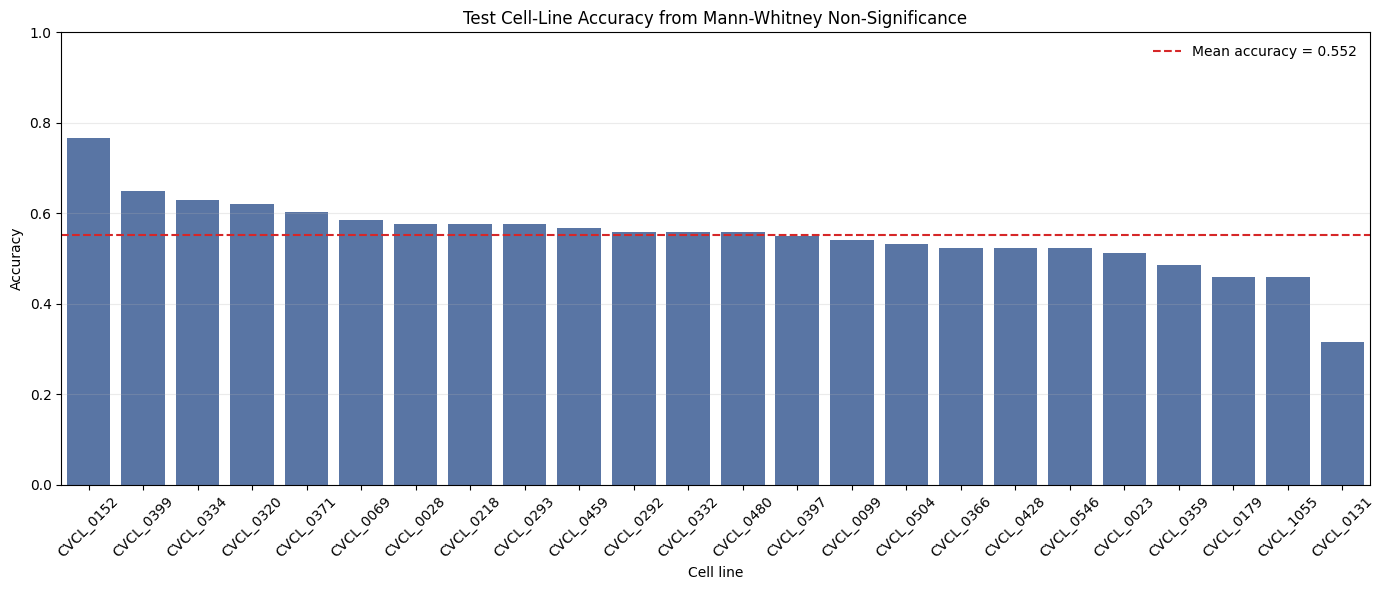

In [11]:
test_prediction_details_df = test_prediction_details_df.copy()
test_prediction_details_df["is_correct_prediction"] = test_prediction_details_df["mann_whitney_pvalue"] > 0.05

test_cell_line_accuracy_df = (
    test_prediction_details_df.groupby("cell_line", as_index=False)
    .agg(
        n_test_samples=("condition_key", "size"),
        n_correct_predictions=("is_correct_prediction", "sum"),
    )
)
test_cell_line_accuracy_df["n_correct_predictions"] = test_cell_line_accuracy_df["n_correct_predictions"].astype(int)
test_cell_line_accuracy_df["cell_line_accuracy"] = (
    test_cell_line_accuracy_df["n_correct_predictions"] / test_cell_line_accuracy_df["n_test_samples"]
)
test_cell_line_accuracy_df = test_cell_line_accuracy_df.sort_values(
    ["cell_line_accuracy", "cell_line"],
    ascending=[False, True],
    ignore_index=True,
)
mean_cell_line_accuracy = float(test_cell_line_accuracy_df["cell_line_accuracy"].mean())

print("Computed test-set cell-line accuracy using mann_whitney_pvalue > 0.05 as the correctness rule.")
display(test_cell_line_accuracy_df)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=test_cell_line_accuracy_df,
    x="cell_line",
    y="cell_line_accuracy",
    color="#4c72b0",
    ax=ax,
)
ax.axhline(
    mean_cell_line_accuracy,
    color="#d62728",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean accuracy = {mean_cell_line_accuracy:.3f}",
)
ax.set_title("Test Cell-Line Accuracy from Mann-Whitney Non-Significance")
ax.set_xlabel("Cell line")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()


## Plot Test Cell-Line DEG Overlap Metrics


Computed test-set top-50 DEG overlap counts and signed nDCG@50 from predicted vs true delta expression.


,cell_line,n_test_samples,mean_top50_deg_match_count,median_top50_deg_match_count,min_top50_deg_match_count,max_top50_deg_match_count
0,CVCL_0293,111,28.513514,29.0,15.0,41.0
1,CVCL_0023,111,27.279279,28.0,19.0,35.0
2,CVCL_0131,111,27.567568,28.0,14.0,39.0
3,CVCL_0320,111,28.432432,28.0,17.0,41.0
4,CVCL_0366,111,26.594595,27.0,17.0,36.0
5,CVCL_0028,111,26.063063,26.0,15.0,36.0
6,CVCL_0152,111,26.333333,26.0,19.0,35.0
7,CVCL_0179,111,25.702703,26.0,15.0,37.0
8,CVCL_0359,111,26.126126,26.0,16.0,34.0
9,CVCL_0480,111,26.081081,26.0,16.0,35.0


,cell_line,n_test_samples,mean_signed_ndcg_at_50,median_signed_ndcg_at_50,min_signed_ndcg_at_50,max_signed_ndcg_at_50
0,CVCL_0293,111,0.690555,0.824353,0.002379,0.958474
1,CVCL_1055,111,0.644028,0.807846,0.012036,0.946189
2,CVCL_0131,111,0.653749,0.790196,0.012953,0.970195
3,CVCL_0320,111,0.586258,0.700530,0.005360,0.943537
4,CVCL_0028,111,0.599488,0.694689,0.070658,0.919839
5,CVCL_0332,111,0.596715,0.690892,0.055030,0.929883
6,CVCL_0366,111,0.586897,0.687795,0.084505,0.921236
7,CVCL_0480,111,0.594459,0.646268,0.200276,0.909940
8,CVCL_0023,111,0.592340,0.637676,0.149142,0.940711
9,CVCL_0359,111,0.569664,0.635336,0.027075,0.927534


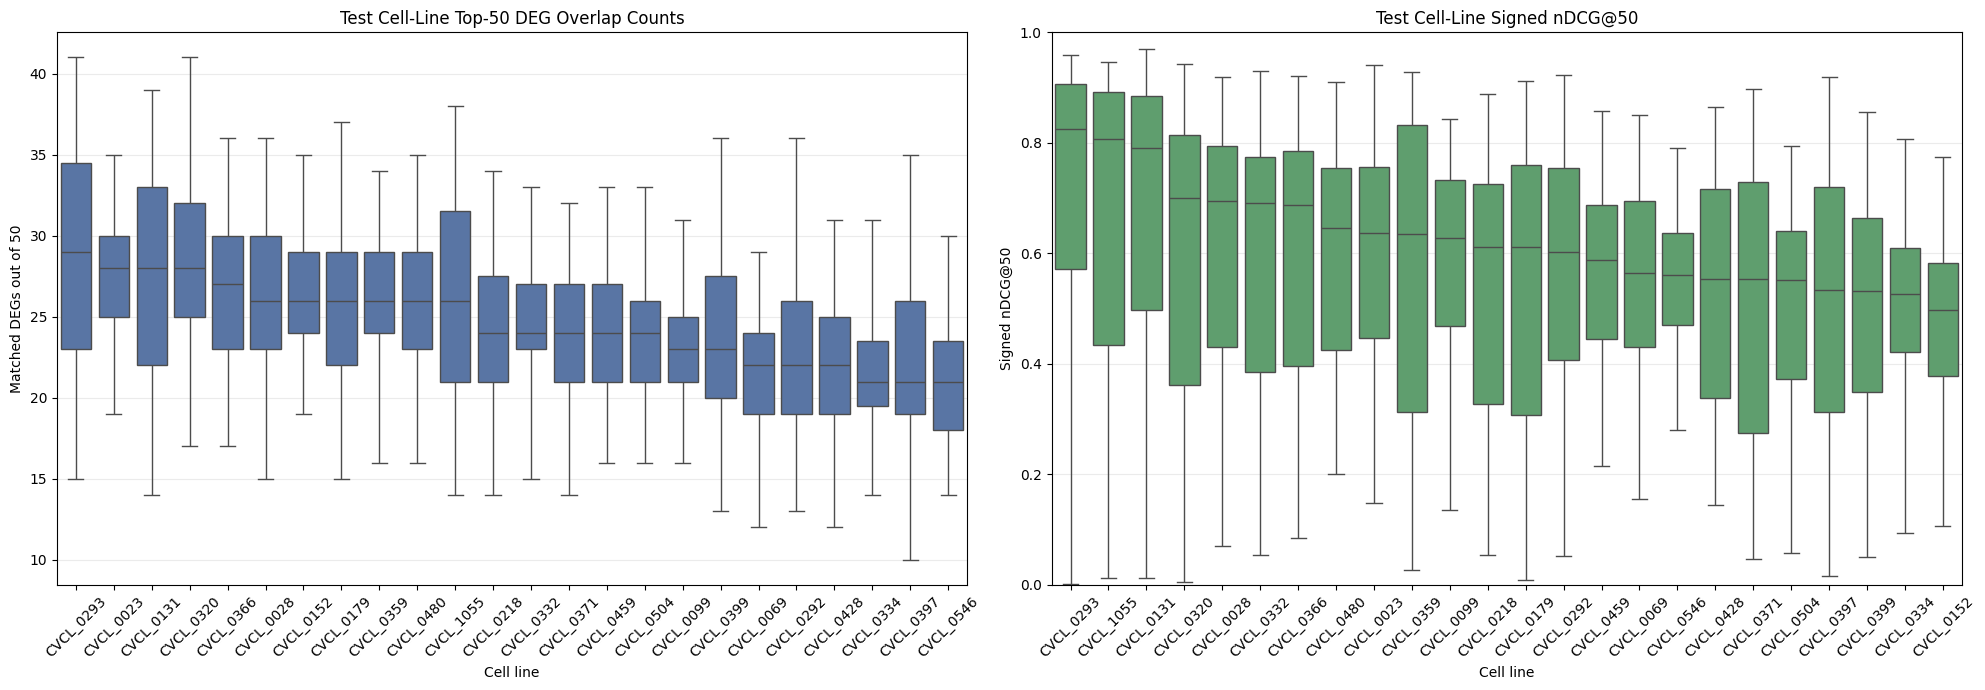

In [12]:
test_cell_line_deg_match_df = (
    test_prediction_details_df.groupby("cell_line", as_index=False)
    .agg(
        n_test_samples=("condition_key", "size"),
        mean_top50_deg_match_count=("top50_deg_match_count", "mean"),
        median_top50_deg_match_count=("top50_deg_match_count", "median"),
        min_top50_deg_match_count=("top50_deg_match_count", "min"),
        max_top50_deg_match_count=("top50_deg_match_count", "max"),
    )
    .sort_values(["median_top50_deg_match_count", "cell_line"], ascending=[False, True], ignore_index=True)
)
test_cell_line_signed_ndcg_df = (
    test_prediction_details_df.groupby("cell_line", as_index=False)
    .agg(
        n_test_samples=("condition_key", "size"),
        mean_signed_ndcg_at_50=("signed_ndcg_at_50", "mean"),
        median_signed_ndcg_at_50=("signed_ndcg_at_50", "median"),
        min_signed_ndcg_at_50=("signed_ndcg_at_50", "min"),
        max_signed_ndcg_at_50=("signed_ndcg_at_50", "max"),
    )
    .sort_values(["median_signed_ndcg_at_50", "cell_line"], ascending=[False, True], ignore_index=True)
)
deg_match_order = test_cell_line_deg_match_df["cell_line"].tolist()
signed_ndcg_order = test_cell_line_signed_ndcg_df["cell_line"].tolist()

print("Computed test-set top-50 DEG overlap counts and signed nDCG@50 from predicted vs true delta expression.")
display(test_cell_line_deg_match_df)
display(test_cell_line_signed_ndcg_df)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
deg_ax, ndcg_ax = axes

sns.boxplot(
    data=test_prediction_details_df,
    x="cell_line",
    y="top50_deg_match_count",
    order=deg_match_order,
    whis=(0, 100),
    color="#4c72b0",
    ax=deg_ax,
)
deg_ax.set_title("Test Cell-Line Top-50 DEG Overlap Counts")
deg_ax.set_xlabel("Cell line")
deg_ax.set_ylabel("Matched DEGs out of 50")
deg_ax.grid(True, axis="y", alpha=0.25)
deg_ax.tick_params(axis="x", rotation=45)

sns.boxplot(
    data=test_prediction_details_df,
    x="cell_line",
    y="signed_ndcg_at_50",
    order=signed_ndcg_order,
    whis=(0, 100),
    color="#55a868",
    ax=ndcg_ax,
)
ndcg_ax.set_title("Test Cell-Line Signed nDCG@50")
ndcg_ax.set_xlabel("Cell line")
ndcg_ax.set_ylabel("Signed nDCG@50")
ndcg_ax.set_ylim(0, 1)
ndcg_ax.grid(True, axis="y", alpha=0.25)
ndcg_ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()


In [ ]:
metric_artifact_paths = write_performance_metrics(
    run_output_dir,
    {
        "evaluation_summary": evaluation_summary_df,
        "retrieval_summary": retrieval_summary_df,
        "test_prediction_details": test_prediction_details_df,
        "test_cell_line_accuracy": test_cell_line_accuracy_df,
        "test_cell_line_deg_match": test_cell_line_deg_match_df,
        "test_cell_line_signed_ndcg": test_cell_line_signed_ndcg_df,
    },
)

metric_artifact_paths